In [1]:
# %%
# =============================================================================
#  CST  –  Constant Strain Triangle  (3 nodes · 6 DOF)
#  Complete notebook – follows Quad4 reference structure exactly
# =============================================================================
#
#  Node layout (CCW):
#
#   3
#   |  \
#   |    \
#   1 ----2
#
#  Reference triangle:  ξ ∈ [0,1],  η ∈ [0, 1-ξ]
#  N1 = 1-ξ-η,  N2 = ξ,  N3 = η
#  B-matrix is CONSTANT (closed-form stiffness)

import numpy as np
from numpy.polynomial.legendre import leggauss

import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.patches import Polygon
from mpl_toolkits.mplot3d import Axes3D
from IPython.display import clear_output
from ipywidgets import interact, FloatSlider, IntSlider, fixed

np.set_printoptions(precision=4, suppress=True, linewidth=200)

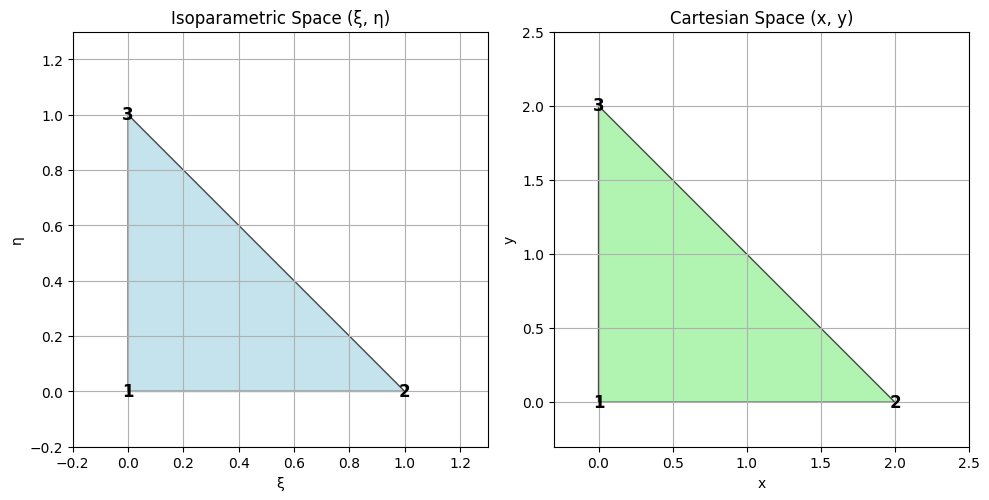

In [2]:
# Define nodal coordinates

nodes_cartesian = np.array([
    [0.0, 0.0],   # Node 1
    [2.0, 0.0],   # Node 2
    [0.0, 2.0],   # Node 3
])

# Isoparametric coordinates

nodes_iso = np.array([
    [0.0, 0.0],   # Node 1
    [1.0, 0.0],   # Node 2
    [0.0, 1.0],   # Node 3
])

# Plot setup
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

# Plot Isoparametric space
ax1 = axes[0]
ax1.add_patch(Polygon(nodes_iso, closed=True, edgecolor='black', facecolor='lightblue', alpha=0.7))
for i, (x, y) in enumerate(nodes_iso, 1):
    ax1.text(x, y, f'{i}', ha='center', va='center', fontsize=12, weight='bold')
ax1.set_title('Isoparametric Space (ξ, η)')
ax1.set_xlim(-0.2, 1.3)
ax1.set_ylim(-0.2, 1.3)
ax1.set_aspect('equal')
ax1.grid(True)
ax1.set_xlabel('ξ')
ax1.set_ylabel('η')

ax2 = axes[1]
ax2.add_patch(Polygon(nodes_cartesian, closed=True, edgecolor='black', facecolor='lightgreen', alpha=0.7))
for i, (x, y) in enumerate(nodes_cartesian, 1):
    ax2.text(x, y, f'{i}', ha='center', va='center', fontsize=12, weight='bold')
ax2.set_title('Cartesian Space (x, y)')
ax2.set_xlim(-0.3, 2.5)
ax2.set_ylim(-0.3, 2.5)
ax2.set_aspect('equal')
ax2.grid(True)
ax2.set_xlabel('x')
ax2.set_ylabel('y')

plt.tight_layout()
plt.show()


In [3]:
# ----------------------------------
# Shape functions and their derivatives
# ----------------------------------

def shape_functions(xi, eta):
    N1 = 1.0 - xi - eta
    N2 = xi
    N3 = eta
    return np.array([[N1], [N2], [N3]])

def shape_function_derivatives(xi, eta):
    dN_dxi  = np.array([-1.0,  1.0,  0.0])
    dN_deta = np.array([-1.0,  0.0,  1.0])
    return dN_dxi, dN_deta


# -------------------------------
# Jacobian matrix and determinant
# -------------------------------

def jacobian_matrix(coords, xi, eta):
    dN_dxi, dN_deta = shape_function_derivatives(xi, eta)
    J = np.zeros((2, 2))
    for i in range(3):
        J[0, 0] += dN_dxi[i]  * coords[i, 0]
        J[0, 1] += dN_dxi[i]  * coords[i, 1]
        J[1, 0] += dN_deta[i] * coords[i, 0]
        J[1, 1] += dN_deta[i] * coords[i, 1]
    return J

def jacobian_determinant(J):
    return np.linalg.det(J)

# ----------------------------------------
# Partial derivatives with respect to x, y
# ----------------------------------------

def shape_function_derivatives_global(coords, xi, eta):
    dN_dxi, dN_deta = shape_function_derivatives(xi, eta)
    J     = jacobian_matrix(coords, xi, eta)
    J_inv = np.linalg.inv(J)
    dN_dx = []
    dN_dy = []
    for i in range(3):
        dN_nat  = np.array([dN_dxi[i], dN_deta[i]])
        dN_phys = J_inv @ dN_nat
        dN_dx.append(dN_phys[0])
        dN_dy.append(dN_phys[1])
    return np.array(dN_dx), np.array(dN_dy)

# ---------------------------
# B matrix (Strain-Displacement)
# ---------------------------

def strain_displacement_matrix(coords, xi, eta):
    dN_dx, dN_dy = shape_function_derivatives_global(coords, xi, eta)
    B = np.zeros((3, 6))
    for i in range(3):
        B[0, 2*i]     = dN_dx[i]
        B[1, 2*i + 1] = dN_dy[i]
        B[2, 2*i]     = dN_dy[i]
        B[2, 2*i + 1] = dN_dx[i]
    return B

def generalized_interpolation(xi, eta, data_matrix):
    N = shape_functions(xi, eta)
    return (data_matrix @ N).flatten()

# -------------------------------
# Utility: Axis limits
# -------------------------------

def get_limits(coords, margin=0.3):
    x_min, y_min = np.min(coords, axis=0)
    x_max, y_max = np.max(coords, axis=0)
    return (x_min - margin, x_max + margin), (y_min - margin, y_max + margin)

def annotate_top_right(ax, value, fmt='.4f'):
    ax.annotate(f'{value:{fmt}}',
                xy=(0.98, 0.98), xycoords='axes fraction',
                fontsize=10, ha='right', va='top',
                bbox=dict(boxstyle='round,pad=0.2', fc='white', alpha=0.8))

def compute_element_area(coords):
    x, y = coords[:, 0], coords[:, 1]
    n = len(x)
    area = 0.0
    for i in range(n):
        area += x[i]*y[(i+1)%n] - x[(i+1)%n]*y[i]
    return 0.5 * abs(area)

def constitutive_matrix(E=210e9, nu=0.3):
    coef = E / (1 - nu**2)
    return coef * np.array([
        [1,     nu,    0],
        [nu,    1,     0],
        [0,     0, (1 - nu) / 2]
    ])


def integrand_trace(coords, xi, eta, E_mat, t=1.0):
    """Compute trace of B^T E B * |J| at a given xi, eta"""
    B = strain_displacement_matrix(coords, xi, eta)
    J = jacobian_matrix(coords, xi, eta)
    detJ = jacobian_determinant(J)
    K_local = B.T @ E_mat @ B
    return t * detJ * np.trace(K_local)

def compute_integrand_matrix(coords, xi, eta, E_mat, t=1.0):
    B = strain_displacement_matrix(coords, xi, eta)
    J = jacobian_matrix(coords, xi, eta)
    detJ = jacobian_determinant(J)

    return t * detJ * (B.T @ E_mat @ B)

def simpson_2d(f_grid, h_xi, h_eta):
    """
    Applies the composite 2D Simpson's rule to a grid f_grid.
    Assumes an odd number of points (e.g., 51 x 51).
    """
    if f_grid.shape[0] % 2 == 0 or f_grid.shape[1] % 2 == 0:
        raise ValueError("Simpson's rule requires an odd number of points in each dimension.")

    m, n = f_grid.shape
    S = 0

    for i in range(m):
        for j in range(n):
            coef_i = 2 + 2*(i % 2)
            coef_j = 2 + 2*(j % 2)
            if i == 0 or i == m-1:
                coef_i = 1
            if j == 0 or j == n-1:
                coef_j = 1
            S += coef_i * coef_j * f_grid[i, j]

    return (h_xi * h_eta / 9) * S

def gauss_points(n):
    """
    Returns Gauss-Legendre quadrature points and weights for [-1, 1].
    """
    pts_1d, w_1d = leggauss(n)
    Xi, Eta = np.meshgrid(pts_1d, pts_1d)
    Wxi, Weta = np.meshgrid(w_1d, w_1d)
    points  = np.column_stack((Xi.flatten(), Eta.flatten()))
    weights = (Wxi * Weta).flatten()
    return points, weights

def gauss_integrate_component(func, idx, coords, E_mat, n_gauss):
    """
    Integrates K_{ii}(xi, eta) over the domain using 2D Gauss-Legendre quadrature.

    - func: function compute_integrand_matrix
    - idx: component index K_{ii}
    - coords: element coordinates
    - E_mat: constitutive matrix
    - n_gauss: quadrature order (e.g., 2 → 2x2 points)

    Returns:
    - integral (float)
    """
    pts_1d, w_1d = leggauss(n_gauss)
    xi_pts = 0.5*(pts_1d + 1.0)
    xi_wts = 0.5*w_1d
    integral = 0.0
    for xi, wi in zip(xi_pts, xi_wts):
        for eta_h, wj in zip(xi_pts, xi_wts):
            eta    = eta_h * (1.0 - xi)
            weight = wi * wj * (1.0 - xi)
            integral += weight * func(coords, xi, eta, E_mat)[idx, idx]
    return integral

# -------------------------------
#  STIFFNESS MATRIX 
# -------------------------------

def compute_stiffness_matrix(coords, E=210e9, nu=0.3, t=1.0, n_gauss=3):
    E_mat = constitutive_matrix(E, nu)
    B     = strain_displacement_matrix(coords, 1/3, 1/3)
    J     = jacobian_matrix(coords, 1/3, 1/3)
    area  = 0.5 * abs(jacobian_determinant(J))
    return B.T @ E_mat @ B * area * t

def check_symmetry(K):
    """
    Checks the symmetry of the stiffness matrix.

    Returns the maximum absolute error between K and its transpose.
    """
    return np.max(np.abs(K - K.T))

def rigid_body_modes():
    """
    Returns displacement vectors for rigid body modes:
    - Translation in x
    - Translation in y
    - Rotation around the centroid
    """
    ux  = np.array([1, 0] * 3, dtype=float)
    uy  = np.array([0, 1] * 3, dtype=float)
    
    # Nodal positions (x, y)
    cx, cy = nodes_cartesian.mean(axis=0)
    rot = []
    for x, y in nodes_cartesian:
        rot += [-(y - cy), (x - cx)]
    rot = np.array(rot)

    return ux, uy, rot

def internal_energy(K, u):
    """
    Computes the internal energy U = 0.5 * uᵀ K u
    """
    return 0.5 * u.T @ K @ u

def verify_rigid_body_modes(K, verbose=True):
    """
    Evaluates internal energy for the 3 rigid body modes and displays results.
    """
    ux, uy, rot = rigid_body_modes()
    
    e_x = internal_energy(K, ux)
    e_y = internal_energy(K, uy)
    e_r = internal_energy(K, rot)
    sym_err = check_symmetry(K)

    if verbose:
        print(f"  Symmetry error      : {sym_err:.6e}  (should be ~0)")
        print(f"  Energy ux  (RBM)    : {e_x:.6e}")
        print(f"  Energy uy  (RBM)    : {e_y:.6e}")
        print(f"  Energy rot (RBM)    : {e_r:.6e}")
    return sym_err, e_x, e_y, e_r


In [4]:
# --- Plotting function ---
def plot_mapping(xi, eta):
    clear_output(wait=True)

    data_matrix = np.vstack([nodes_cartesian[:, 0], nodes_cartesian[:, 1]])
    x_mapped, y_mapped = generalized_interpolation(xi, eta, data_matrix)
    iso_xlim,  iso_ylim  = get_limits(nodes_iso,       0.2)
    cart_xlim, cart_ylim = get_limits(nodes_cartesian, 0.5)

    fig = plt.figure(figsize=(20, 10), dpi=100, constrained_layout=True)
    gs  = fig.add_gridspec(2, 5, height_ratios=[1.1, 1])

    ax1    = fig.add_subplot(gs[0, 0])
    ax2    = fig.add_subplot(gs[0, 1])
    axB    = fig.add_subplot(gs[0, 2:5])
    axs_sf = [fig.add_subplot(gs[1, i]) for i in range(3)]

    # --- Isoparametric view ---
    ax1.add_patch(Polygon(nodes_iso, closed=True, edgecolor='black', facecolor='lightblue', alpha=0.6))
    for i, (x, y) in enumerate(nodes_iso, 1):
        ax1.text(x, y, str(i), ha='center', va='center', fontsize=12, fontweight='bold')
    ax1.plot(xi, eta, 'ro', markersize=10)
    ax1.set_title('Isoparametric Space $(\\xi, \\eta)$', fontsize=12)
    ax1.set_xlim(*iso_xlim); ax1.set_ylim(*iso_ylim)
    ax1.set_aspect('equal'); ax1.grid(True)
    ax1.set_xlabel('ξ'); ax1.set_ylabel('η')

    # --- Cartesian view ---
    ax2.add_patch(Polygon(nodes_cartesian, closed=True, edgecolor='black', facecolor='lightgreen', alpha=0.6))
    for i, (x, y) in enumerate(nodes_cartesian, 1):
        ax2.text(x, y, str(i), ha='center', va='center', fontsize=12, fontweight='bold')
    ax2.plot(x_mapped, y_mapped, 'ro', markersize=10)
    ax2.set_title('Cartesian Space $(x, y)$', fontsize=12)
    ax2.set_xlim(*cart_xlim); ax2.set_ylim(*cart_ylim)
    ax2.set_aspect('equal'); ax2.grid(True)
    ax2.set_xlabel('x'); ax2.set_ylabel('y')

    # B matrix table
    B = strain_displacement_matrix(nodes_cartesian, xi, eta)
    axB.axis('off')
    col_labels = [f'$u_{i+1}$' for i in range(6)]
    row_labels  = [r'$\varepsilon_x$', r'$\varepsilon_y$', r'$\gamma_{xy}$']
    table_data  = [[f'{B[r, c]:.2e}' for c in range(6)] for r in range(3)]
    tbl = axB.table(cellText=table_data, rowLabels=row_labels, colLabels=col_labels,
                    loc='center', cellLoc='center', edges='closed')
    tbl.scale(1.2, 1.8); tbl.set_fontsize(10)
    axB.set_title('Strain-Displacement Matrix $[B]$  (constant over element)', fontsize=14, pad=10)

    # --- Shape function plots ---
    res = 50
    xi_g  = np.linspace(0, 1, res)
    eta_g = np.linspace(0, 1, res)
    Xi, Eta = np.meshgrid(xi_g, eta_g)
    mask = (Xi + Eta) <= 1.0

    names = ['$N_1 = 1-\\xi-\\eta$', '$N_2 = \\xi$', '$N_3 = \\eta$']
    N_pt  = shape_functions(xi, eta).flatten()

    for k, ax in enumerate(axs_sf):
        Ni_grid = np.full((res, res), np.nan)
        for i in range(res):
            for j in range(res):
                if mask[i, j]:
                    Ni_grid[i, j] = shape_functions(Xi[i,j], Eta[i,j]).flatten()[k]

        cf = ax.contourf(Xi, Eta, Ni_grid, levels=20, cmap='viridis')
        ax.contour(Xi, Eta, Xi + Eta, levels=[1.0], colors='k', linewidths=1.0)
        ax.plot(xi, eta, 'ro', markersize=6)
        ax.set_title(names[k], fontsize=11)
        ax.set_xlim(-0.02, 1.05); ax.set_ylim(-0.02, 1.05)
        ax.set_aspect('equal')
        ax.set_xlabel('ξ'); ax.set_ylabel('η')
        ax.grid(True)
        annotate_top_right(ax, N_pt[k])
        fig.colorbar(cf, ax=ax)

    plt.show()

# --- Widget setup ---
interact(plot_mapping,
         xi =FloatSlider(min=0.0, max=1.0, step=0.05, value=0.0, description='ξ'),
         eta=FloatSlider(min=0.0, max=1.0, step=0.05, value=0.0, description='η'))


interactive(children=(FloatSlider(value=0.0, description='ξ', max=1.0, step=0.05), FloatSlider(value=0.0, desc…

<function __main__.plot_mapping(xi, eta)>

In [5]:
# Plotting
def plot_mapping_3d(xi, eta):
    clear_output(wait=True)
    
    data_matrix = np.vstack([nodes_cartesian[:, 0], nodes_cartesian[:, 1]])
    x_mapped, y_mapped = generalized_interpolation(xi, eta, data_matrix)
    iso_xlim,  iso_ylim  = get_limits(nodes_iso,       0.2)
    cart_xlim, cart_ylim = get_limits(nodes_cartesian, 0.5)

    fig = plt.figure(figsize=(20, 8), dpi=100, constrained_layout=True)
    gs  = fig.add_gridspec(2, 4, height_ratios=[1.1, 1])

    ax1    = fig.add_subplot(gs[0, 0])
    ax2    = fig.add_subplot(gs[0, 1])
    axs_3d = [fig.add_subplot(gs[1, i], projection='3d') for i in range(3)]

    # Isoparametric view
    ax1.add_patch(Polygon(nodes_iso, closed=True, edgecolor='black', facecolor='lightblue', alpha=0.6))
    for i, (x, y) in enumerate(nodes_iso, 1):
        ax1.text(x, y, str(i), ha='center', va='center', fontsize=12, fontweight='bold')
    ax1.plot(xi, eta, 'ro', markersize=10)
    ax1.set_title('Isoparametric Space $(\\xi, \\eta)$', fontsize=13)
    ax1.set_xlim(*iso_xlim); ax1.set_ylim(*iso_ylim)
    ax1.set_aspect('equal'); ax1.grid(True)

    # Cartesian view
    ax2.add_patch(Polygon(nodes_cartesian, closed=True, edgecolor='black', facecolor='lightgreen', alpha=0.6))
    for i, (x, y) in enumerate(nodes_cartesian, 1):
        ax2.text(x, y, str(i), ha='center', va='center', fontsize=12, fontweight='bold')
    ax2.plot(x_mapped, y_mapped, 'ro', markersize=10)
    ax2.set_title('Cartesian Space $(x, y)$', fontsize=13)
    ax2.set_xlim(*cart_xlim); ax2.set_ylim(*cart_ylim)
    ax2.set_aspect('equal'); ax2.grid(True)

    # 3D surfaces
    res = 50
    xi_g  = np.linspace(0, 1, res); eta_g = np.linspace(0, 1, res)
    Xi, Eta = np.meshgrid(xi_g, eta_g)
    mask = (Xi + Eta) <= 1.0
    N_pt = shape_functions(xi, eta).flatten()

    for k, ax in enumerate(axs_3d):
        Ni_grid = np.full((res, res), np.nan)
        for i in range(res):
            for j in range(res):
                if mask[i, j]:
                    Ni_grid[i, j] = shape_functions(Xi[i,j], Eta[i,j]).flatten()[k]

        ax.plot_surface(Xi, Eta, Ni_grid, cmap='viridis', edgecolor='k', linewidth=0.2, alpha=0.9)
        ax.scatter(xi, eta, N_pt[k], color='r', s=30)
        ax.set_title(f'$N_{k+1}(\\xi, \\eta)$', fontsize=11)
        ax.set_xlabel('ξ'); ax.set_ylabel('η'); ax.set_zlabel(f'$N_{k+1}$')
        ax.view_init(elev=30, azim=-45)
        ax.set_xlim(0, 1); ax.set_ylim(0, 1); ax.set_zlim(0, 1)

    fig.suptitle('CST Shape Functions as 3D Surfaces', fontsize=15, fontweight='bold')
    plt.show()

interact(plot_mapping_3d,
         xi =FloatSlider(min=0.0, max=1.0, step=0.05, value=0.0, description='ξ'),
         eta=FloatSlider(min=0.0, max=1.0, step=0.05, value=0.0, description='η'))


interactive(children=(FloatSlider(value=0.0, description='ξ', max=1.0, step=0.05), FloatSlider(value=0.0, desc…

<function __main__.plot_mapping_3d(xi, eta)>

In [6]:
shape_functions(1.0, 0.0)

array([[0.],
       [1.],
       [0.]])

In [7]:
data_matrix = np.vstack([nodes_cartesian[:, 0], nodes_cartesian[:, 1]])
x_mapped, y_mapped = generalized_interpolation(0.5, 0.5, data_matrix)

In [8]:
# --- Main visualization function ---
def plot_mapping_full(xi, eta):
    clear_output(wait=True)

    data_matrix = np.vstack([nodes_cartesian[:, 0], nodes_cartesian[:, 1]])
    x_mapped, y_mapped = generalized_interpolation(xi, eta, data_matrix)
    iso_xlim,  iso_ylim  = get_limits(nodes_iso,       0.2)
    cart_xlim, cart_ylim = get_limits(nodes_cartesian, 0.5)

    fig = plt.figure(figsize=(20, 20), dpi=100, constrained_layout=True)
    gs  = fig.add_gridspec(4, 5, height_ratios=[1.2, 1, 1, 1])

    ax1      = fig.add_subplot(gs[0, 0])
    ax2      = fig.add_subplot(gs[0, 1])
    axB      = fig.add_subplot(gs[0, 2:5])
    axs_sf   = [fig.add_subplot(gs[1, i]) for i in range(3)]
    axs_dxi  = [fig.add_subplot(gs[2, i]) for i in range(3)]
    axs_deta = [fig.add_subplot(gs[3, i]) for i in range(3)]

    # Isoparametric view
    ax1.add_patch(Polygon(nodes_iso, closed=True, edgecolor='black', facecolor='lightblue', alpha=0.6))
    for i, (x, y) in enumerate(nodes_iso, 1):
        ax1.text(x, y, str(i), ha='center', va='center', fontsize=12, fontweight='bold')
    ax1.plot(xi, eta, 'ro', markersize=10)
    ax1.set_title('Isoparametric Space $(\\xi, \\eta)$', fontsize=12)
    ax1.set_xlim(*iso_xlim); ax1.set_ylim(*iso_ylim)
    ax1.set_aspect('equal'); ax1.grid(True)

    # Cartesian view
    ax2.add_patch(Polygon(nodes_cartesian, closed=True, edgecolor='black', facecolor='lightgreen', alpha=0.6))
    for i, (x, y) in enumerate(nodes_cartesian, 1):
        ax2.text(x, y, str(i), ha='center', va='center', fontsize=12, fontweight='bold')
    ax2.plot(x_mapped, y_mapped, 'ro', markersize=10)
    ax2.set_title('Cartesian Space $(x, y)$', fontsize=12)
    ax2.set_xlim(*cart_xlim); ax2.set_ylim(*cart_ylim)
    ax2.set_aspect('equal'); ax2.grid(True)

    # B matrix table
    B = strain_displacement_matrix(nodes_cartesian, xi, eta)
    axB.axis('off')
    tbl = axB.table(
        cellText=[[f'{B[r, c]:.2e}' for c in range(6)] for r in range(3)],
        rowLabels=[r'$\varepsilon_x$', r'$\varepsilon_y$', r'$\gamma_{xy}$'],
        colLabels=[f'$u_{i+1}$' for i in range(6)],
        loc='center', cellLoc='center', edges='closed')
    tbl.scale(1.2, 1.8); tbl.set_fontsize(10)
    axB.set_title('Strain-Displacement Matrix $[B]$', fontsize=14, pad=10)

    # Grid
    res = 50
    xi_g  = np.linspace(0, 1, res); eta_g = np.linspace(0, 1, res)
    Xi, Eta = np.meshgrid(xi_g, eta_g)
    mask = (Xi + Eta) <= 1.0

    N_pt  = shape_functions(xi, eta).flatten()
    d1_pt, d2_pt = shape_function_derivatives(xi, eta)

    for k in range(3):
        Ni_g   = np.full((res, res), np.nan)
        dxi_g  = np.full((res, res), np.nan)
        deta_g = np.full((res, res), np.nan)

        for i in range(res):
            for j in range(res):
                if mask[i, j]:
                    Ni_g[i,j]   = shape_functions(Xi[i,j], Eta[i,j]).flatten()[k]
                    d1, d2      = shape_function_derivatives(Xi[i,j], Eta[i,j])
                    dxi_g[i,j]  = d1[k]
                    deta_g[i,j] = d2[k]

        # Ni contour
        cf = axs_sf[k].contourf(Xi, Eta, Ni_g, levels=20, cmap='viridis')
        axs_sf[k].contour(Xi, Eta, Xi+Eta, levels=[1.0], colors='k', linewidths=1.0)
        axs_sf[k].plot(xi, eta, 'ro', markersize=6)
        axs_sf[k].set_title(f'$N_{k+1}(\\xi, \\eta)$', fontsize=11)
        axs_sf[k].set_xlim(-0.02, 1.05); axs_sf[k].set_ylim(-0.02, 1.05)
        axs_sf[k].set_aspect('equal'); axs_sf[k].grid(True)
        axs_sf[k].set_xlabel('ξ'); axs_sf[k].set_ylabel('η')
        annotate_top_right(axs_sf[k], N_pt[k])
        fig.colorbar(cf, ax=axs_sf[k])

        # dNi/dxi
        cf2 = axs_dxi[k].contourf(Xi, Eta, dxi_g, levels=20, cmap='coolwarm')
        axs_dxi[k].contour(Xi, Eta, Xi+Eta, levels=[1.0], colors='k', linewidths=1.0)
        axs_dxi[k].plot(xi, eta, 'ro', markersize=6)
        axs_dxi[k].set_title(f'$\\partial N_{k+1}/\\partial \\xi$', fontsize=11)
        axs_dxi[k].set_xlim(-0.02, 1.05); axs_dxi[k].set_ylim(-0.02, 1.05)
        axs_dxi[k].set_aspect('equal'); axs_dxi[k].grid(True)
        axs_dxi[k].set_xlabel('ξ'); axs_dxi[k].set_ylabel('η')
        annotate_top_right(axs_dxi[k], d1_pt[k])
        fig.colorbar(cf2, ax=axs_dxi[k])

        # dNi/deta
        cf3 = axs_deta[k].contourf(Xi, Eta, deta_g, levels=20, cmap='cividis')
        axs_deta[k].contour(Xi, Eta, Xi+Eta, levels=[1.0], colors='k', linewidths=1.0)
        axs_deta[k].plot(xi, eta, 'ro', markersize=6)
        axs_deta[k].set_title(f'$\\partial N_{k+1}/\\partial \\eta$', fontsize=11)
        axs_deta[k].set_xlim(-0.02, 1.05); axs_deta[k].set_ylim(-0.02, 1.05)
        axs_deta[k].set_aspect('equal'); axs_deta[k].grid(True)
        axs_deta[k].set_xlabel('ξ'); axs_deta[k].set_ylabel('η')
        annotate_top_right(axs_deta[k], d2_pt[k])
        fig.colorbar(cf3, ax=axs_deta[k])

    plt.show()

interact(plot_mapping_full,
         xi =FloatSlider(min=0.0, max=1.0, step=0.05, value=0.0, description='ξ'),
         eta=FloatSlider(min=0.0, max=1.0, step=0.05, value=0.0, description='η'))

interactive(children=(FloatSlider(value=0.0, description='ξ', max=1.0, step=0.05), FloatSlider(value=0.0, desc…

<function __main__.plot_mapping_full(xi, eta)>

In [9]:
area = compute_element_area(nodes_cartesian)

def plot_jacobian_fields(xi, eta):
    clear_output(wait=True)

    res = 50
    xi_g  = np.linspace(0, 1, res); eta_g = np.linspace(0, 1, res)
    Xi, Eta = np.meshgrid(xi_g, eta_g)
    mask = (Xi + Eta) <= 1.0

    J11 = np.full((res,res),np.nan); J12 = np.full((res,res),np.nan)
    J21 = np.full((res,res),np.nan); J22 = np.full((res,res),np.nan)
    detJ_grid = np.full((res,res),np.nan)

    for i in range(res):
        for j in range(res):
            if mask[i, j]:
                J = jacobian_matrix(nodes_cartesian, Xi[i,j], Eta[i,j])
                J11[i,j]=J[0,0]; J12[i,j]=J[0,1]
                J21[i,j]=J[1,0]; J22[i,j]=J[1,1]
                detJ_grid[i,j] = np.linalg.det(J)

    data_matrix = np.vstack([nodes_cartesian[:,0], nodes_cartesian[:,1]])
    x_mapped, y_mapped = generalized_interpolation(xi, eta, data_matrix)
    iso_xlim,  iso_ylim  = get_limits(nodes_iso,       0.2)
    cart_xlim, cart_ylim = get_limits(nodes_cartesian, 0.5)

    J_at_pt    = jacobian_matrix(nodes_cartesian, xi, eta)
    detJ_at_pt = jacobian_determinant(J_at_pt)

    fig, axs = plt.subplots(3, 3, figsize=(18, 14), dpi=100, constrained_layout=True)

    # [0,0] iso space
    axs[0,0].add_patch(Polygon(nodes_iso, closed=True, edgecolor='black', facecolor='lightblue', alpha=0.6))
    for i,(x,y) in enumerate(nodes_iso,1):
        axs[0,0].text(x,y,str(i),ha='center',va='center',fontsize=12,fontweight='bold')
    axs[0,0].plot(xi,eta,'ro',markersize=8)
    axs[0,0].set_title('Isoparametric Space $(\\xi, \\eta)$')
    axs[0,0].set_xlim(*iso_xlim); axs[0,0].set_ylim(*iso_ylim)
    axs[0,0].set_aspect('equal'); axs[0,0].grid(True)

    # [0,1] cart space
    axs[0,1].add_patch(Polygon(nodes_cartesian, closed=True, edgecolor='black', facecolor='lightgreen', alpha=0.6))
    for i,(x,y) in enumerate(nodes_cartesian,1):
        axs[0,1].text(x,y,str(i),ha='center',va='center',fontsize=12,fontweight='bold')
    axs[0,1].plot(x_mapped,y_mapped,'ro',markersize=8)
    axs[0,1].set_title('Physical Space $(x, y)$')
    axs[0,1].set_xlim(*cart_xlim); axs[0,1].set_ylim(*cart_ylim)
    axs[0,1].set_aspect('equal'); axs[0,1].grid(True)

    # [0,2] det J
    c3 = axs[0,2].contourf(Xi, Eta, detJ_grid, levels=20, cmap='viridis')
    axs[0,2].contour(Xi,Eta,Xi+Eta,levels=[1.0],colors='k',linewidths=1.0)
    axs[0,2].plot(xi,eta,'ro'); axs[0,2].set_title(r'Determinant $|J|$')
    axs[0,2].set_aspect('equal'); fig.colorbar(c3, ax=axs[0,2])
    annotate_top_right(axs[0,2], detJ_at_pt, fmt='.2e')

    # [1,0] J11
    c11 = axs[1,0].contourf(Xi, Eta, J11, levels=20, cmap='coolwarm')
    axs[1,0].contour(Xi,Eta,Xi+Eta,levels=[1.0],colors='k',linewidths=1.0)
    axs[1,0].plot(xi,eta,'ro'); axs[1,0].set_title(r'$\partial x / \partial \xi$')
    axs[1,0].set_aspect('equal'); fig.colorbar(c11, ax=axs[1,0])
    annotate_top_right(axs[1,0], J_at_pt[0,0], fmt='.2e')

    # [1,1] J12
    c12 = axs[1,1].contourf(Xi, Eta, J12, levels=20, cmap='coolwarm')
    axs[1,1].contour(Xi,Eta,Xi+Eta,levels=[1.0],colors='k',linewidths=1.0)
    axs[1,1].plot(xi,eta,'ro'); axs[1,1].set_title(r'$\partial y / \partial \xi$')
    axs[1,1].set_aspect('equal'); fig.colorbar(c12, ax=axs[1,1])
    annotate_top_right(axs[1,1], J_at_pt[0,1], fmt='.2e')

    # [1,2] det J / area
    xx = axs[1,2].contourf(Xi, Eta, detJ_grid/area, levels=20, cmap='viridis')
    axs[1,2].contour(Xi,Eta,Xi+Eta,levels=[1.0],colors='k',linewidths=1.0)
    axs[1,2].plot(xi,eta,'ro'); axs[1,2].set_title(r'Determinant $|J|$ / Area')
    axs[1,2].set_aspect('equal'); fig.colorbar(xx, ax=axs[1,2])
    annotate_top_right(axs[1,2], detJ_at_pt/area, fmt='.3f')

    # [2,0] J21
    c21 = axs[2,0].contourf(Xi, Eta, J21, levels=20, cmap='cividis')
    axs[2,0].contour(Xi,Eta,Xi+Eta,levels=[1.0],colors='k',linewidths=1.0)
    axs[2,0].plot(xi,eta,'ro'); axs[2,0].set_title(r'$\partial x / \partial \eta$')
    axs[2,0].set_aspect('equal'); fig.colorbar(c21, ax=axs[2,0])
    annotate_top_right(axs[2,0], J_at_pt[1,0], fmt='.2e')

    # [2,1] J22
    c22 = axs[2,1].contourf(Xi, Eta, J22, levels=20, cmap='cividis')
    axs[2,1].contour(Xi,Eta,Xi+Eta,levels=[1.0],colors='k',linewidths=1.0)
    axs[2,1].plot(xi,eta,'ro'); axs[2,1].set_title(r'$\partial y / \partial \eta$')
    axs[2,1].set_aspect('equal'); fig.colorbar(c22, ax=axs[2,1])
    annotate_top_right(axs[2,1], J_at_pt[1,1], fmt='.2e')

    axs[2,2].axis('off')
    plt.show()

interact(plot_jacobian_fields,
         xi =FloatSlider(min=0.0, max=1.0, step=0.05, value=0.0, description='ξ'),
         eta=FloatSlider(min=0.0, max=1.0, step=0.05, value=0.0, description='η'))


interactive(children=(FloatSlider(value=0.0, description='ξ', max=1.0, step=0.05), FloatSlider(value=0.0, desc…

<function __main__.plot_jacobian_fields(xi, eta)>

In [10]:
# Material properties
E=210e9  # Young's modulus in Pa
nu=0.3  # Poisson's ratio
t=0.01  # Thickness in m

Emat = constitutive_matrix(E=E, nu=nu)

In [11]:
def plot_stiffness_integrand(E_mat, xi_eval=0.0, eta_eval=0.0):
    clear_output(wait=True)

    res = 50
    xi_g  = np.linspace(0, 1, res); eta_g = np.linspace(0, 1, res)
    Xi, Eta = np.meshgrid(xi_g, eta_g)
    mask = (Xi + Eta) <= 1.0
    Z = np.full((res, res), np.nan)

    for i in range(res):
        for j in range(res):
            if mask[i, j]:
                Z[i,j] = integrand_trace(nodes_cartesian, Xi[i,j], Eta[i,j], E_mat, t)

    Z_point = integrand_trace(nodes_cartesian, xi_eval, eta_eval, E_mat, t)

    fig = plt.figure(figsize=(16, 6))

    # Contour plot
    ax1 = fig.add_subplot(1, 2, 1)
    c = ax1.contourf(Xi, Eta, Z, levels=30, cmap='viridis')
    ax1.contour(Xi, Eta, Xi+Eta, levels=[1.0], colors='k', linewidths=1.0)
    ax1.plot(xi_eval, eta_eval, 'ro')
    annotate_top_right(ax1, Z_point, fmt='.2e')
    ax1.set_title(r'Trace of Integrand $B^T E B \, |J|$')
    ax1.set_xlabel('ξ'); ax1.set_ylabel('η')
    fig.colorbar(c, ax=ax1); ax1.grid(True); ax1.set_aspect('equal')

    # 3D surface plot
    ax2 = fig.add_subplot(1, 2, 2, projection='3d')
    ax2.plot_surface(Xi, Eta, Z, cmap='viridis', edgecolor='k', alpha=0.95, linewidth=0.1)
    ax2.scatter(xi_eval, eta_eval, Z_point, color='r', s=30)
    ax2.set_title('Integrand in 3D')
    ax2.set_xlabel('ξ'); ax2.set_ylabel('η'); ax2.set_zlabel('Scalar Value')
    ax2.view_init(elev=30, azim=-45)

    plt.tight_layout()
    plt.show()

interact(lambda xi, eta: plot_stiffness_integrand(Emat, xi, eta),
         xi =FloatSlider(min=0.0, max=1.0, step=0.05, value=0.0, description='ξ'),
         eta=FloatSlider(min=0.0, max=1.0, step=0.05, value=0.0, description='η'))


interactive(children=(FloatSlider(value=0.0, description='ξ', max=1.0, step=0.05), FloatSlider(value=0.0, desc…

<function __main__.<lambda>(xi, eta)>

In [12]:
def plot_stiffness_diagonal_interactive(E_mat, xi=0.0, eta=0.0):
    clear_output(wait=True)

    res = 50
    xi_g  = np.linspace(0, 1, res); eta_g = np.linspace(0, 1, res)
    Xi, Eta = np.meshgrid(xi_g, eta_g)

    mask = (Xi + Eta) <= 1.0

    fig, axs = plt.subplots(2, 3, figsize=(20, 10), constrained_layout=True)
    axs = axs.flatten()

    for idx in range(6):
        Z = np.full((res, res), np.nan)
        for r in range(res):
            for c in range(res):
                if mask[r, c]:
                    K_loc = compute_integrand_matrix(nodes_cartesian, Xi[r,c], Eta[r,c], E_mat, t)
                    Z[r, c] = K_loc[idx, idx]

        Z_point = compute_integrand_matrix(nodes_cartesian, xi, eta, E_mat, t)[idx, idx]
        
        ax = axs[idx]
        contour = ax.contourf(Xi, Eta, Z, levels=30, cmap='viridis')
        ax.contour(Xi, Eta, Xi+Eta, levels=[1.0], colors='k', linewidths=1.0)
        ax.plot(xi, eta, 'ro')
        annotate_top_right(ax, Z_point, fmt='.2e')
        ax.set_title(rf'$K_{{{idx+1},{idx+1}}}(\xi, \eta)$', fontsize=11)
        ax.set_xlabel('ξ'); ax.set_ylabel('η')
        ax.set_aspect('equal'); ax.grid(True)
        fig.colorbar(contour, ax=ax)

    fig.suptitle(r'Diagonal Components of Integrand $B^T E B \cdot |J|$',
                 fontsize=16, fontweight='bold')
    plt.show()

interact(plot_stiffness_diagonal_interactive,
         E_mat=fixed(Emat),
         xi =FloatSlider(min=0.0, max=1.0, step=0.05, value=0.0, description='ξ'),
         eta=FloatSlider(min=0.0, max=1.0, step=0.05, value=0.0, description='η'))


interactive(children=(FloatSlider(value=0.0, description='ξ', max=1.0, step=0.05), FloatSlider(value=0.0, desc…

<function __main__.plot_stiffness_diagonal_interactive(E_mat, xi=0.0, eta=0.0)>

In [13]:
def plot_stiffness_diagonal_interactive_3D(E_mat, xi=0.0, eta=0.0):
    clear_output(wait=True)

    res = 51
    xi_g  = np.linspace(0, 1, res); eta_g = np.linspace(0, 1, res)
    Xi, Eta = np.meshgrid(xi_g, eta_g)
    mask = (Xi + Eta) <= 1.0
    h = 1.0 / (res - 1)

    fig = plt.figure(figsize=(24, 10), constrained_layout=True)
    axs = [fig.add_subplot(2, 3, i+1, projection='3d') for i in range(6)]

    for idx, ax in enumerate(axs):
        Z = np.full((res, res), np.nan)
        for r in range(res):
            for c in range(res):
                if mask[r, c]:
                    K_loc = compute_integrand_matrix(nodes_cartesian, Xi[r,c], Eta[r,c], E_mat, t)
                    Z[r, c] = K_loc[idx, idx]

        K_pt   = compute_integrand_matrix(nodes_cartesian, xi, eta, E_mat, t)[idx, idx]
        volume = simpson_2d(Z, h, h)

        ax.plot_surface(Xi, Eta, Z, cmap='viridis', edgecolor='k', linewidth=0.1, alpha=0.95)
        ax.scatter(xi, eta, K_pt, color='r', s=30)
        ax.set_xlabel('ξ'); ax.set_ylabel('η')
        ax.set_zlabel(rf'$K_{{{idx+1},{idx+1}}}$')
        ax.set_title(rf'$K_{{{idx+1},{idx+1}}}(\xi, \eta)$', fontsize=10)
        ax.view_init(elev=30, azim=-45)
        ax.text2D(0.5, -0.15, f'Vol = {volume:.2e}', transform=ax.transAxes,
                  ha='center', fontsize=9, bbox=dict(boxstyle='round', fc='wheat', alpha=0.3))

    fig.suptitle(r'Diagonal Components (3D) of Integrand $B^T E B \cdot |J|$',
                 fontsize=16, fontweight='bold')
    plt.show()

interact(plot_stiffness_diagonal_interactive_3D,
         E_mat=fixed(Emat),
         xi =FloatSlider(min=0.0, max=1.0, step=0.05, value=0.0, description='ξ'),
         eta=FloatSlider(min=0.0, max=1.0, step=0.05, value=0.0, description='η'))

interactive(children=(FloatSlider(value=0.0, description='ξ', max=1.0, step=0.05), FloatSlider(value=0.0, desc…

<function __main__.plot_stiffness_diagonal_interactive_3D(E_mat, xi=0.0, eta=0.0)>

In [14]:
def plot_stiffness_diagonal_gauss(E_mat, xi=0.0, eta=0.0, n_gauss=3):
    clear_output(wait=True)


    res = 50
    xi_g  = np.linspace(0, 1, res); eta_g = np.linspace(0, 1, res)
    Xi, Eta = np.meshgrid(xi_g, eta_g)
    mask = (Xi + Eta) <= 1.0

    # Gauss points on triangle
    pts_1d, w_1d = leggauss(n_gauss)
    xi_pts = 0.5*(pts_1d+1); xi_wts = 0.5*w_1d
    gauss_tri = []
    for xv, wv in zip(xi_pts, xi_wts):
        for eh, wh in zip(xi_pts, xi_wts):
            ev = eh*(1-xv); weight = wv*wh*(1-xv)
            gauss_tri.append((xv, ev, weight))

    fig, axs = plt.subplots(2, 3, figsize=(22, 10), constrained_layout=True)
    axs = axs.flatten()

    for idx in range(6):
        Z = np.full((res, res), np.nan)
        for r in range(res):
            for c in range(res):
                if mask[r, c]:
                    K_loc = compute_integrand_matrix(nodes_cartesian, Xi[r,c], Eta[r,c], E_mat, t)
                    Z[r, c] = K_loc[idx, idx]

        Z_point = compute_integrand_matrix(nodes_cartesian, xi, eta, E_mat, t)[idx, idx]
        ax = axs[idx]
        contour = ax.contourf(Xi, Eta, Z, levels=30, cmap='viridis')
        ax.contour(Xi, Eta, Xi+Eta, levels=[1.0], colors='k', linewidths=1.0)
        ax.plot(xi, eta, 'ro', label='Current point')

        for (xi_i, eta_i, wi) in gauss_tri:
            ax.plot(xi_i, eta_i, 'ko', markersize=6, zorder=5)
            ax.text(xi_i, eta_i + 0.05, f'({xi_i:.2f},{eta_i:.2f})', fontsize=7,
                    ha='center', va='bottom',
                    bbox=dict(boxstyle='round,pad=0.2', fc='white', alpha=0.85), zorder=6)
            ax.text(xi_i, eta_i - 0.05, f'$w$={wi:.3f}', fontsize=7,
                    ha='center', va='top',
                    bbox=dict(boxstyle='round,pad=0.2', fc='white', alpha=0.85), zorder=6)

        annotate_top_right(ax, Z_point, fmt='.2e')
        ax.set_title(rf'$K_{{{idx+1},{idx+1}}}(\xi, \eta)$', fontsize=11)
        ax.set_xlabel('ξ'); ax.set_ylabel('η')
        ax.set_aspect('equal'); ax.grid(True)
        fig.colorbar(contour, ax=ax)

    fig.suptitle(r'Diagonal Components $B^T E B \cdot |J|$ with Gauss Points and Weights',
                 fontsize=16, fontweight='bold')
    plt.show()

interact(plot_stiffness_diagonal_gauss,
         E_mat  =fixed(Emat),
         xi     =FloatSlider(min=0.0, max=1.0, step=0.05, value=0.0, description='ξ'),
         eta    =FloatSlider(min=0.0, max=1.0, step=0.05, value=0.0, description='η'),
         n_gauss=IntSlider(min=1, max=5, step=1, value=1, description='Gauss'))


interactive(children=(FloatSlider(value=0.0, description='ξ', max=1.0, step=0.05), FloatSlider(value=0.0, desc…

<function __main__.plot_stiffness_diagonal_gauss(E_mat, xi=0.0, eta=0.0, n_gauss=3)>

In [15]:
def plot_stiffness_diagonal_3D_gauss(E_mat, xi=0.0, eta=0.0, n_gauss=3):
    clear_output(wait=True)


    res = 51
    xi_g  = np.linspace(0, 1, res); eta_g = np.linspace(0, 1, res)
    Xi, Eta = np.meshgrid(xi_g, eta_g)
    mask = (Xi + Eta) <= 1.0

    fig = plt.figure(figsize=(24, 10), constrained_layout=True)
    axs = [fig.add_subplot(2, 3, i+1, projection='3d') for i in range(6)]

    for idx, ax in enumerate(axs):
        Z = np.full((res, res), np.nan)
        for r in range(res):
            for c in range(res):
                if mask[r, c]:
                    K_loc = compute_integrand_matrix(nodes_cartesian, Xi[r,c], Eta[r,c], E_mat, t)
                    Z[r, c] = K_loc[idx, idx]

        K_pt   = compute_integrand_matrix(nodes_cartesian, xi, eta, E_mat, t)[idx, idx]
        volume = gauss_integrate_component(compute_integrand_matrix, idx, nodes_cartesian, E_mat, n_gauss)

        ax.plot_surface(Xi, Eta, Z, cmap='viridis', edgecolor='k', linewidth=0.1, alpha=0.95)
        ax.scatter(xi, eta, K_pt, color='r', s=30)
        ax.set_xlabel('ξ'); ax.set_ylabel('η')
        ax.set_zlabel(rf'$K_{{{idx+1},{idx+1}}}$')
        ax.set_title(rf'$K_{{{idx+1},{idx+1}}}(\xi, \eta)$', fontsize=10)
        ax.view_init(elev=30, azim=-45)
        ax.text2D(0.5, -0.15, f'Gauss ({n_gauss}×{n_gauss}) Vol = {volume:.2e}',
                  transform=ax.transAxes, ha='center', fontsize=9,
                  bbox=dict(boxstyle='round', fc='wheat', alpha=0.3))

    fig.suptitle('Diagonal Components (3D) with Gauss Quadrature',
                 fontsize=16, fontweight='bold')
    plt.show()

interact(plot_stiffness_diagonal_3D_gauss,
         E_mat  =fixed(Emat),
         xi     =FloatSlider(min=0.0, max=1.0, step=0.05, value=0.0, description='ξ'),
         eta    =FloatSlider(min=0.0, max=1.0, step=0.05, value=0.0, description='η'),
         n_gauss=IntSlider(min=1, max=5, step=1, value=3, description='Gauss'))

interactive(children=(FloatSlider(value=0.0, description='ξ', max=1.0, step=0.05), FloatSlider(value=0.0, desc…

<function __main__.plot_stiffness_diagonal_3D_gauss(E_mat, xi=0.0, eta=0.0, n_gauss=3)>

In [16]:
np.set_printoptions(precision=3, suppress=True, linewidth=200)

K = compute_stiffness_matrix(nodes_cartesian, E=E, nu=nu, t=t, n_gauss=3)
verify_rigid_body_modes(K)
print("Stiffness Matrix [K]:")
print(K)

  Symmetry error      : 0.000000e+00  (should be ~0)
  Energy ux  (RBM)    : -2.980232e-08
  Energy uy  (RBM)    : 0.000000e+00
  Energy rot (RBM)    : -3.729548e-08
Stiffness Matrix [K]:
[[ 1.558e+09  7.500e+08 -1.154e+09 -4.038e+08 -4.038e+08 -3.462e+08]
 [ 7.500e+08  1.558e+09 -3.462e+08 -4.038e+08 -4.038e+08 -1.154e+09]
 [-1.154e+09 -3.462e+08  1.154e+09  0.000e+00  0.000e+00  3.462e+08]
 [-4.038e+08 -4.038e+08  0.000e+00  4.038e+08  4.038e+08  0.000e+00]
 [-4.038e+08 -4.038e+08  0.000e+00  4.038e+08  4.038e+08  0.000e+00]
 [-3.462e+08 -1.154e+09  3.462e+08  0.000e+00  0.000e+00  1.154e+09]]
